<p align="center"><img src="logo.png" alt="amorphouspy" width="260"></p>

# SiO₂ Glass via Melt-Quench (amorphouspy)

This notebook demonstrates the minimal workflow for producing a silica glass structure from a melt-quench simulation using **amorphouspy**.

Steps:
1. Build a random SiO₂ starting structure
2. Generate the SHIK interatomic potential
3. Run the melt-quench simulation via LAMMPS
4. Inspect the quenched glass — density, RDF, coordination

In [1]:
# as a safe guard untill the latest version is published
#!git clone https://github.com/glasagent/amorphouspy.git
#!cd amorphouspy
#!pip install -e amorphouspy

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from ase.data import atomic_masses

import amorphouspy as am
from amorphouspy.lammps.potentials.potential import generate_potential

## 1. Composition and Structure

Pure SiO₂ glass. `get_structure_dict` places atoms randomly in a cubic box whose side length is derived from the empirical Fluegel density model (≈ 2.2 g/cm³ for SiO₂).

In [3]:
composition = {"SiO2": 1.0}

struct_dict = am.get_structure_dict(composition, target_atoms=300)
print(f"Box length : {struct_dict['box']:.3f} Å")
print(f"Atom count : {struct_dict['total_atoms']}")
print(f"Element counts: {struct_dict['element_counts']}")

atoms = am.get_ase_structure(struct_dict)
print(atoms)

Box length : 16.754 Å
Atom count : 300
Element counts: {'Si': 100, 'O': 200}
Atoms(symbols='O200Si100', pbc=True, cell=[16.75386769066847, 16.75386769066847, 16.75386769066847], id=..., initial_charges=..., masses=..., mmcharges=..., type=...)


## 2. Interatomic Potential

SHIK (Sundararaman et al.) is the recommended potential for SiO₂ and aluminosilicate glasses. It uses a Buckingham + r⁻²⁴ short-range form with DSF Coulomb electrostatics.

Passing `melt=True` appends a Langevin + NVE/limit pre-equilibration block at 4000 K to the LAMMPS config — this block is used only in the first heating stage and stripped automatically in later protocol stages.

In [4]:
potential = generate_potential(struct_dict, potential_type="shik", melt=True)

print(potential[["Name", "Model", "Species"]])
print()
print("--- LAMMPS config lines ---")
for line in potential.loc[0, "Config"]:
    print(line, end="")

   Name Model  Species
0  SHIK  SHIK  [O, Si]

--- LAMMPS config lines ---
# S. Sundararaman et al.,
# for silica glass, J. Chem. Phys. 2018, 148, 19, https://doi.org/10.1063/1.5023707
# for alkali and alkaline-earth aluminosilicate glasses, J. Chem. Phys. 2019, 150, 15, https://doi.org/10.1063/1.5079663
# for borate glasses with mixed network formers, J. Chem. Phys. 2020, 152, 10, https://doi.org/10.1063/1.5142605
# for alkaline earth silicate and borate glasses, Shih et al. J. Non-Cryst. Sol. 2021, 565, 120853, https://doi.org/10.1016/j.jnoncrysol.2021.120853

dimension 3
atom_style charge


### Group Definitions ###
group O type 1
group Si type 2

### Charges ###
set type 1 charge -0.88775
set type 2 charge 1.7755

### SHIK Potential ###
pair_style hybrid/overlay coul/dsf 0.2 10.0 table spline 10000
pair_coeff * * coul/dsf
pair_coeff 1 1 table "/Users/achrafatila/Documents/Workflows/Amorphouspy_PMD_workflowStore/amorphouspy_meltquench/shik_tables/table_O_O.tbl" SHIK_Buck_r24 8.0
pai

## 3. Melt-Quench Simulation

The SHIK protocol runs six stages automatically:

| Stage | Ensemble | Purpose |
|-------|----------|---------|
| 1 | NVT at T_high | Melt the random structure |
| 2 | NVT equil. at T_high | Equilibrate the melt |
| 3 | NPT at T_high, 0.1 GPa | Relax volume |
| 4 | NPT quench T_high → T_low | Cool to glass |
| 5 | NPT at T_low, 0 GPa | Anneal |
| 6 | NVT at T_low | Final equilibration + frame sampling |

The parameters below use `equilibration_steps=10000` and fast rates (`1e15 K/s`) for a quick demonstration. For production, remove `equilibration_steps` and use `cooling_rate=1e12` K/s.

In [5]:
result = am.melt_quench_simulation(
    structure=atoms,
    potential=potential,
    temperature_high=4000.0,   # K — melt temperature
    temperature_low=300.0,     # K — final glass temperature
    timestep=1.0,              # fs
    heating_rate=1e15,         # K/s  (fast — for demo only)
    cooling_rate=1e15,         # K/s  (fast — for demo only)
    n_print=100,
    equilibration_steps=10000, # override protocol defaults — remove for production
    seed=42,
)

glass   = result["structure"]
history = result["result"]    # list[dict | None], one entry per protocol stage

print("Final structure:", glass)
print(f"Protocol stages completed: {len(history)}")

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity LogStep. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalize

Final structure: Atoms(symbols='O200Si100', pbc=True, cell=[[16.42118455039476, 3.016522664677337e-15, 3.0165226646773364e-15], [-3.0165226646773364e-15, 16.42118455039476, 3.016522664677337e-15], [-3.016522664677336e-15, -3.0165226646773364e-15, 16.42118455039476]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)
Protocol stages completed: 6


/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


## 4. Temperature and Volume Traces

Each protocol stage returns a thermo dict with keys `steps`, `temperature`, `energy_pot`, `volume`, etc.

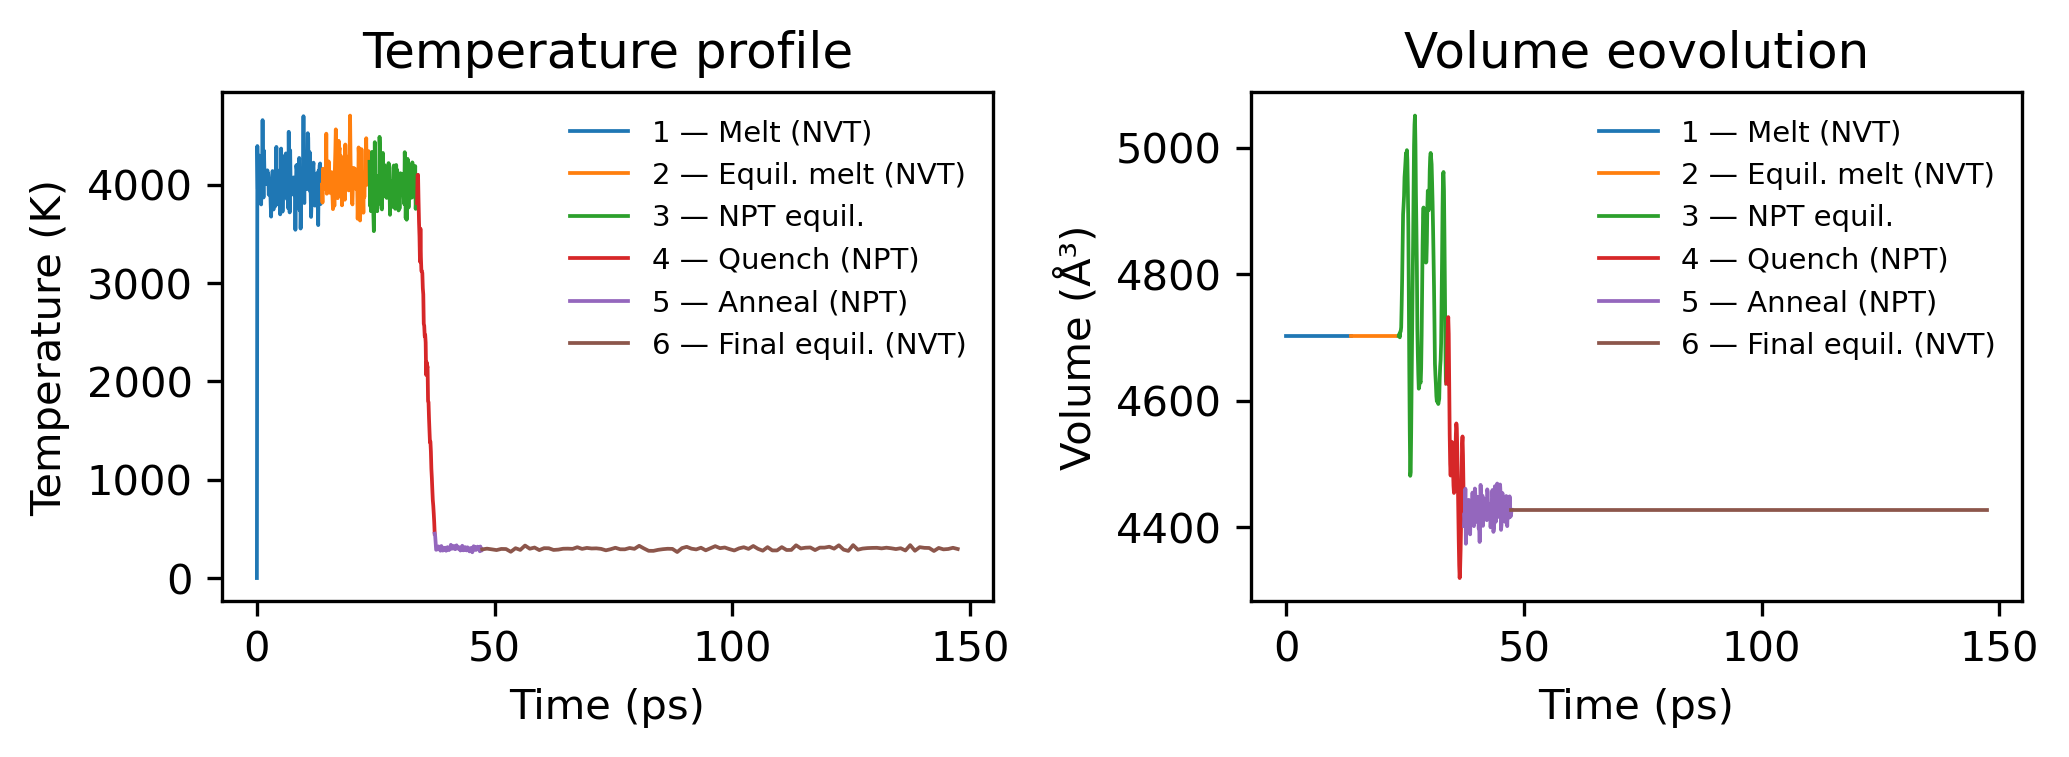

In [6]:
stage_labels = [
    "1 — Melt (NVT)",
    "2 — Equil. melt (NVT)",
    "3 — NPT equil.",
    "4 — Quench (NPT)",
    "5 — Anneal (NPT)",
    "6 — Final equil. (NVT)",
]

fig, axes = plt.subplots(1, 2, figsize=(2 * 3.5, 3.5/1.3333), dpi=300)
colors = plt.cm.tab10.colors
step_offset = 0

for i, (stage, label, color) in enumerate(zip(history, stage_labels, colors)):
    if stage is None:
        continue
    steps = np.asarray(stage.get("steps", stage.get("step", [])))
    time_ps = (steps + step_offset) * 1e-3  # 1 fs timestep → ps

    if "temperature" in stage:
        axes[0].plot(time_ps, stage["temperature"], lw=0.9, color=color, label=label)
    if "volume" in stage:
        axes[1].plot(time_ps, stage["volume"], lw=0.9, color=color, label=label)

    if len(steps):
        step_offset += int(steps[-1])

for ax, ylabel, title in zip(
    axes,
    ["Temperature (K)", "Volume (Å³)"],
    ["Temperature profile", "Volume eovolution"],
):
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7, frameon=False)

plt.tight_layout()
plt.show()

## 5. Glass Density

In [7]:
def compute_density(structure):
    mass_amu   = sum(atomic_masses[n] for n in structure.get_atomic_numbers())
    volume_cm3 = structure.get_volume() * 1e-24  # Å³ → cm³
    return (mass_amu * 1.66054e-24) / volume_cm3


rho_sim   = compute_density(glass)
rho_model = am.get_glass_density_from_model(composition)

print(f"Simulated density : {rho_sim:.3f} g/cm³")
print(f"Fluegel model     : {rho_model:.3f} g/cm³")

Simulated density : 2.253 g/cm³
Fluegel model     : 2.122 g/cm³


## 6. Radial Distribution Functions

The Si-O first peak should sit near 1.62 Å and the O-O peak near 2.65 Å, both characteristic of tetrahedral SiO₄ units.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


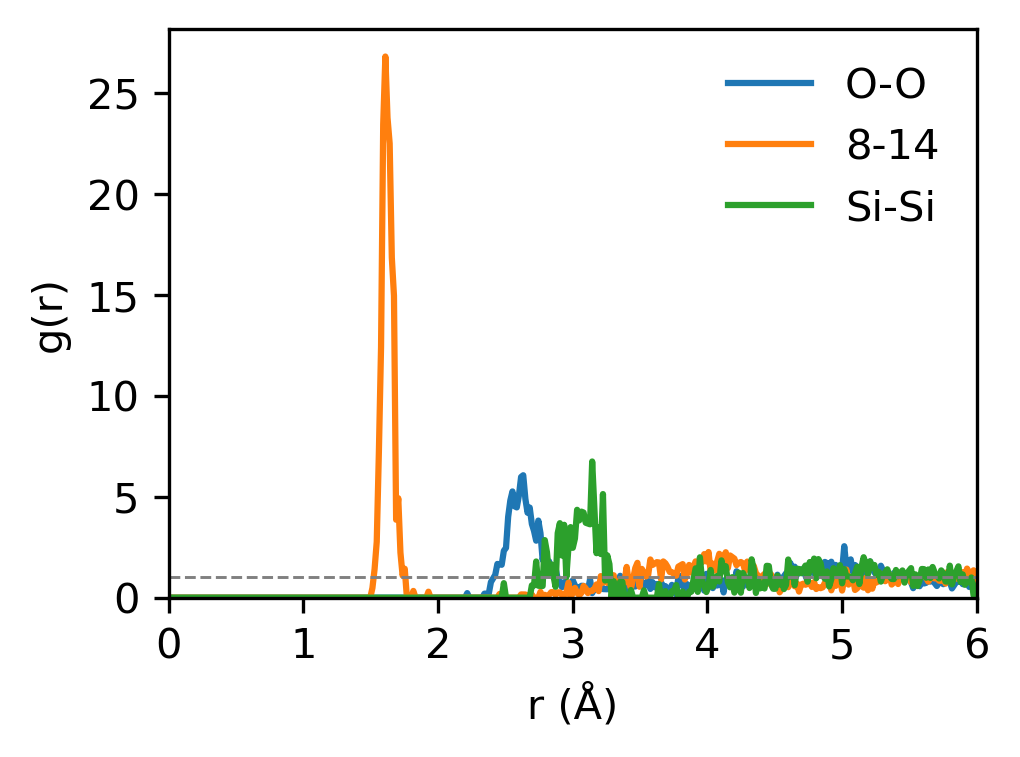

In [8]:
r, rdfs, cumcn = am.compute_rdf(
    structure=glass,
    r_max=8.0,
    n_bins=500,
    type_pairs=[(14, 8), (8, 8), (14, 14)],  # Si-O, O-O, Si-Si
)

pair_labels = {(14, 8): "Si-O", (8, 8): "O-O", (14, 14): "Si-Si"}

fig, ax = plt.subplots(figsize=(3.5, 3.5/1.3333), dpi=300)
for (zi, zj), g in rdfs.items():
    ax.plot(r, g, label=pair_labels.get((zi, zj), f"{zi}-{zj}"))
ax.axhline(1, ls="--", color="gray", lw=0.7)
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_xlim(0, 6)
ax.set_ylim(0, None)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Si Coordination Number

Virtually all Si atoms should be 4-fold coordinated (SiO₄ tetrahedra) in a well-relaxed silica glass.

In [9]:
# Use the first RDF minimum (~2.3 Å for Si-O) as the coordination cutoff
si_o_pair = (8, 14)
r_cutoff = 2.0
print(f"Si-O cutoff (first minimum): {r_cutoff:.3f} Å")

cn_dist = am.compute_coordination(glass, target_type=14, neighbor_types=[8], cutoff=r_cutoff)
print(f"Si coordination distribution: {dict(sorted(cn_dist.items()))}")

Si-O cutoff (first minimum): 2.000 Å
Si coordination distribution: {4: 99.0, 5: 1.0}


## 8. Save the Glass Structure

In [10]:
from ase.io import write

write("SiO2_glass.extxyz", glass)
print("Saved SiO2_glass.extxyz")

Saved SiO2_glass.extxyz
